Name: Ronit Pawar
Course: Advanced Big Data and Data Mining (MSCS-634-B01) 
Lab 1: Data Visualization, Data Preprocessing, and Statistical Analysis Using Python in Jupyter Notebook

In [5]:
#Step 1: Data Collection
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("seattle-weather.xls")

df.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


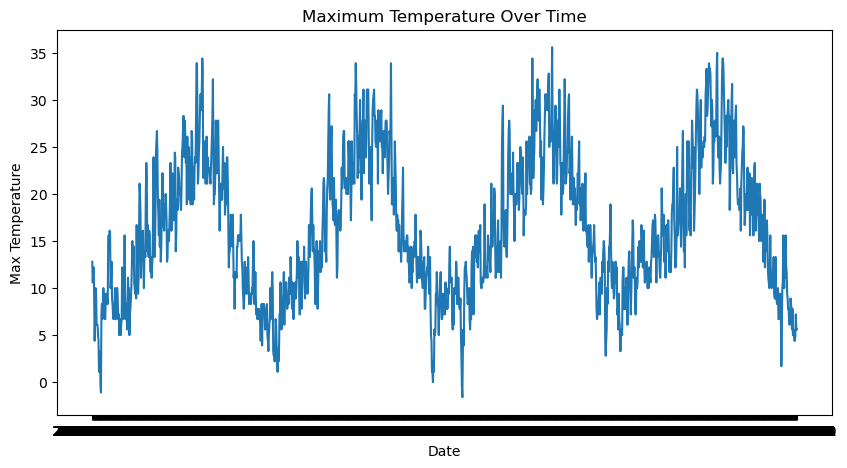

In [6]:
#Step 2: Data Visualization
#Line Plots
plt.figure(figsize=(10,5))
plt.plot(df["date"], df["temp_max"])
plt.title("Maximum Temperature Over Time")
plt.xlabel("Date")
plt.ylabel("Max Temperature")
plt.show()

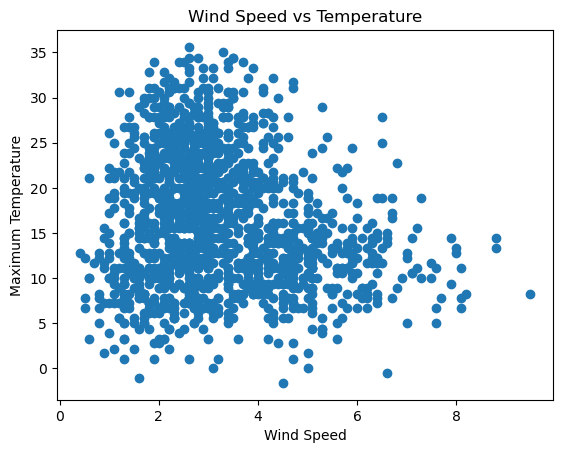

In [7]:
#Scatter Plots
plt.scatter(df["wind"], df["temp_max"])
plt.xlabel("Wind Speed")
plt.ylabel("Maximum Temperature")
plt.title("Wind Speed vs Temperature")
plt.show()

In [14]:
#Step 3: Data Preprocessing 
#1. Handling Missing Values
df.isnull().sum()

date             0
precipitation    0
temp_max         0
temp_min         0
wind             0
weather          0
dtype: int64

In [17]:
#2. Outlier Detection and Removal
Q1 = df["temp_max"].quantile(0.25)
Q3 = df["temp_max"].quantile(0.75)

IQR = Q3 - Q1

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

Q1: 10.6
Q3: 22.2
IQR: 11.6


In [18]:
#Calculate Outlier Boundaries
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -6.799999999999999
Upper Bound: 39.599999999999994


In [20]:
#Identify Outliers
outliers = df[(df["temp_max"] < lower_bound) | (df["temp_max"] > upper_bound)]
outliers

,date,precipitation,temp_max,temp_min,wind,weather


In [19]:
#Remove Outliers
df_clean = df[(df["temp_max"] >= lower_bound) & (df["temp_max"] <= upper_bound)]

df_clean.head()

,date,precipitation,temp_max,temp_min,wind,weather
0,2012-01-01,0.0,12.8,5.0,4.7,drizzle
1,2012-01-02,10.9,10.6,2.8,4.5,rain
2,2012-01-03,0.8,11.7,7.2,2.3,rain
3,2012-01-04,20.3,12.2,5.6,4.7,rain
4,2012-01-05,1.3,8.9,2.8,6.1,rain


In [21]:
#3. Data Reduction
#Dataset Before Reduction
df.head()
df.shape

(1461, 6)

In [22]:
#Sampling (Reduce Data Size)
df_sample = df.sample(frac=0.3, random_state=42)
df_sample.head()
df_sample.shape

(438, 6)

In [23]:
#Dimension Elimination
df_reduced = df_sample.drop(columns=["date"])
df_reduced.head()
df_reduced.shape

(438, 5)

In [24]:
#4. Data Scaling and Discretization
df_reduced.head()

,precipitation,temp_max,temp_min,wind,weather
892,0.0,23.9,11.1,2.7,sun
1105,5.8,7.8,6.1,0.5,rain
413,0.0,9.4,4.4,3.4,rain
522,0.0,26.7,12.2,2.5,sun
1036,1.8,13.3,7.2,2.9,rain


In [25]:
#Min-Max Scaling
min_val = df_reduced["temp_max"].min()
max_val = df_reduced["temp_max"].max()

df_reduced["temp_max_scaled"] = (df_reduced["temp_max"] - min_val) / (max_val - min_val)

df_reduced.head()

,precipitation,temp_max,temp_min,wind,weather,temp_max_scaled
892,0.0,23.9,11.1,2.7,sun,0.684685
1105,5.8,7.8,6.1,0.5,rain,0.201201
413,0.0,9.4,4.4,3.4,rain,0.249249
522,0.0,26.7,12.2,2.5,sun,0.768769
1036,1.8,13.3,7.2,2.9,rain,0.366366


In [26]:
#Discretization
bins = [0, 10, 20, 30, 50]

labels = ["Cold", "Mild", "Warm", "Hot"]

df_reduced["temp_category"] = pd.cut(df_reduced["temp_max"], bins=bins, labels=labels)

df_reduced.head()

,precipitation,temp_max,temp_min,wind,weather,temp_max_scaled,temp_category
892,0.0,23.9,11.1,2.7,sun,0.684685,Warm
1105,5.8,7.8,6.1,0.5,rain,0.201201,Cold
413,0.0,9.4,4.4,3.4,rain,0.249249,Cold
522,0.0,26.7,12.2,2.5,sun,0.768769,Warm
1036,1.8,13.3,7.2,2.9,rain,0.366366,Mild


In [27]:
#Step 4: Statistical Analysis
#1. General Overview of Data
df_reduced.info()

<class 'pandas.core.frame.DataFrame'>
Index: 438 entries, 892 to 798
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   precipitation    438 non-null    float64 
 1   temp_max         438 non-null    float64 
 2   temp_min         438 non-null    float64 
 3   wind             438 non-null    float64 
 4   weather          438 non-null    object  
 5   temp_max_scaled  438 non-null    float64 
 6   temp_category    438 non-null    category
dtypes: category(1), float64(5), object(1)
memory usage: 22.8+ KB


In [28]:
df_reduced.describe()

,precipitation,temp_max,temp_min,wind,temp_max_scaled
count,438.000000,438.000000,438.000000,438.000000,438.000000
mean,3.037671,16.281507,8.130365,3.211872,0.455901
std,6.739913,7.296455,5.085427,1.445120,0.219113
min,0.000000,1.100000,-6.600000,0.400000,0.000000
25%,0.000000,11.100000,4.400000,2.200000,0.300300
50%,0.000000,15.000000,8.300000,2.950000,0.417417
75%,2.950000,21.700000,12.200000,4.000000,0.618619
max,54.100000,34.400000,18.300000,9.500000,1.000000


In [29]:
#2. Central Tendency Measures
df_reduced["temp_max"].min()

np.float64(1.1)

In [30]:
df_reduced["temp_max"].max()

np.float64(34.4)

In [31]:
df_reduced["temp_max"].mean()

np.float64(16.28150684931507)

In [32]:
df_reduced["temp_max"].median()

np.float64(15.0)

In [33]:
df_reduced["temp_max"].mode()

0    12.8
Name: temp_max, dtype: float64

In [34]:
#3. Dispersion Measures
temp_range = df_reduced["temp_max"].max() - df_reduced["temp_max"].min()
print("Range:", temp_range)

Range: 33.3


In [35]:
Q1 = df_reduced["temp_max"].quantile(0.25)
Q2 = df_reduced["temp_max"].quantile(0.50)
Q3 = df_reduced["temp_max"].quantile(0.75)

print("Q1:", Q1)
print("Q2 (Median):", Q2)
print("Q3:", Q3)

Q1: 11.1
Q2 (Median): 15.0
Q3: 21.7


In [36]:
IQR = Q3 - Q1

print("Interquartile Range (IQR):", IQR)

Interquartile Range (IQR): 10.6


In [37]:
variance = df_reduced["temp_max"].var()

print("Variance:", variance)

Variance: 53.23826133976991


In [38]:
std_dev = df_reduced["temp_max"].std()

print("Standard Deviation:", std_dev)

Standard Deviation: 7.296455395585579


In [39]:
#4. Correlation Analysis
df_reduced.corr(numeric_only=True)
correlation_matrix = df_reduced.corr(numeric_only=True)

correlation_matrix

,precipitation,temp_max,temp_min,wind,temp_max_scaled
precipitation,1.000000,-0.246501,-0.096347,0.320854,-0.246501
temp_max,-0.246501,1.000000,0.878269,-0.176626,1.000000
temp_min,-0.096347,0.878269,1.000000,-0.059992,0.878269
wind,0.320854,-0.176626,-0.059992,1.000000,-0.176626
temp_max_scaled,-0.246501,1.000000,0.878269,-0.176626,1.000000
